# 🚗 Car Resale Price Prediction using Machine Learning Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split,cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [3]:
df = pd.read_csv('car_resale_prices.csv')
df.head()

,Unnamed: 0,full_name,resale_price,registered_year,engine_capacity,insurance,transmission_type,kms_driven,owner_type,fuel_type,max_power,seats,mileage,body_type,city
0,0,2017 Maruti Baleno 1.2 Alpha,₹ 5.45 Lakh,2017,1197 cc,Third Party insurance,Manual,"40,000 Kms",First Owner,Petrol,83.1bhp,5.0,21.4 kmpl,Hatchback,Agra
1,1,2018 Tata Hexa XTA,₹ 10 Lakh,2018,2179 cc,Third Party insurance,Automatic,"70,000 Kms",First Owner,Diesel,153.86bhp,7.0,17.6 kmpl,MUV,Agra
2,2,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra
3,3,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra
4,4,2009 Hyundai i10 Magna 1.1,₹ 1.60 Lakh,2009,1086 cc,Third Party insurance,Manual,"80,000 Kms",First Owner,Petrol,68.05bhp,5.0,19.81 kmpl,Hatchback,Agra


In [4]:
df.shape

(17446, 15)

In [5]:
df.isnull().sum()

Unnamed: 0             0
full_name              0
resale_price           0
registered_year       69
engine_capacity       14
insurance              7
transmission_type      0
kms_driven             3
owner_type            45
fuel_type              0
max_power            102
seats                 10
mileage              508
body_type              0
city                   0
dtype: int64

In [6]:
df['registered_year'] = df['full_name'].apply(lambda x: x.split(' ')[0]).astype(int)

In [7]:
df['registered_year'].isnull().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17446 entries, 0 to 17445
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         17446 non-null  int64  
 1   full_name          17446 non-null  object 
 2   resale_price       17446 non-null  object 
 3   registered_year    17446 non-null  int64  
 4   engine_capacity    17432 non-null  object 
 5   insurance          17439 non-null  object 
 6   transmission_type  17446 non-null  object 
 7   kms_driven         17443 non-null  object 
 8   owner_type         17401 non-null  object 
 9   fuel_type          17446 non-null  object 
 10  max_power          17344 non-null  object 
 11  seats              17436 non-null  float64
 12  mileage            16938 non-null  object 
 13  body_type          17446 non-null  object 
 14  city               17446 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 2.0+ MB


In [9]:
df.head()

,Unnamed: 0,full_name,resale_price,registered_year,engine_capacity,insurance,transmission_type,kms_driven,owner_type,fuel_type,max_power,seats,mileage,body_type,city
0,0,2017 Maruti Baleno 1.2 Alpha,₹ 5.45 Lakh,2017,1197 cc,Third Party insurance,Manual,"40,000 Kms",First Owner,Petrol,83.1bhp,5.0,21.4 kmpl,Hatchback,Agra
1,1,2018 Tata Hexa XTA,₹ 10 Lakh,2018,2179 cc,Third Party insurance,Automatic,"70,000 Kms",First Owner,Diesel,153.86bhp,7.0,17.6 kmpl,MUV,Agra
2,2,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra
3,3,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra
4,4,2009 Hyundai i10 Magna 1.1,₹ 1.60 Lakh,2009,1086 cc,Third Party insurance,Manual,"80,000 Kms",First Owner,Petrol,68.05bhp,5.0,19.81 kmpl,Hatchback,Agra


# **Formating Numerical data**

In [10]:
num_cols = ['seats', 'registered_year']

In [11]:
def format_price(resale_price):
    split = resale_price.split(' ')
    k = len(split)
    if (k==2):
        return float(str(split[1]).replace(',', ''))
    elif(split[-1] == 'Lakh'):
        return float(str(split[1]))*100000
    return float(str(split[1]))*100000

df['num_price'] = df['resale_price'].apply(format_price)
num_cols.append('num_price')

df.head()

,Unnamed: 0,full_name,resale_price,registered_year,engine_capacity,insurance,transmission_type,kms_driven,owner_type,fuel_type,max_power,seats,mileage,body_type,city,num_price
0,0,2017 Maruti Baleno 1.2 Alpha,₹ 5.45 Lakh,2017,1197 cc,Third Party insurance,Manual,"40,000 Kms",First Owner,Petrol,83.1bhp,5.0,21.4 kmpl,Hatchback,Agra,545000.0
1,1,2018 Tata Hexa XTA,₹ 10 Lakh,2018,2179 cc,Third Party insurance,Automatic,"70,000 Kms",First Owner,Diesel,153.86bhp,7.0,17.6 kmpl,MUV,Agra,1000000.0
2,2,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra,450000.0
3,3,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra,450000.0
4,4,2009 Hyundai i10 Magna 1.1,₹ 1.60 Lakh,2009,1086 cc,Third Party insurance,Manual,"80,000 Kms",First Owner,Petrol,68.05bhp,5.0,19.81 kmpl,Hatchback,Agra,160000.0


### KM's Driven

In [12]:
def format_kms(kms_driven):
    if kms_driven.split(' ')[1] != "Kms":
        print(kms_driven.split(' ')[1])
    return str(kms_driven.split(' ')[0]).replace(',', '')

In [13]:
df['num_kms'] = df['kms_driven'].str.replace(',', '').str.split().str[0].astype(float)
num_cols.append('num_kms')

In [14]:
df.head(2)

,Unnamed: 0,full_name,resale_price,registered_year,engine_capacity,insurance,transmission_type,kms_driven,owner_type,fuel_type,max_power,seats,mileage,body_type,city,num_price,num_kms
0,0,2017 Maruti Baleno 1.2 Alpha,₹ 5.45 Lakh,2017,1197 cc,Third Party insurance,Manual,"40,000 Kms",First Owner,Petrol,83.1bhp,5.0,21.4 kmpl,Hatchback,Agra,545000.0,40000.0
1,1,2018 Tata Hexa XTA,₹ 10 Lakh,2018,2179 cc,Third Party insurance,Automatic,"70,000 Kms",First Owner,Diesel,153.86bhp,7.0,17.6 kmpl,MUV,Agra,1000000.0,70000.0


# Engine Capacity

In [16]:
def format_engine(engine_capacity):
    if engine.capacity.split(' ')[1] != 'cc':
        print(engine_capacity.split(' ')[1])

df['num_engine'] = df['engine_capacity'].str.replace(',', '').str.split().str[0].astype(float)
num_cols.append('num_engine')
df.head(2)

,Unnamed: 0,full_name,resale_price,registered_year,engine_capacity,insurance,transmission_type,kms_driven,owner_type,fuel_type,max_power,seats,mileage,body_type,city,num_price,num_kms,num_engine
0,0,2017 Maruti Baleno 1.2 Alpha,₹ 5.45 Lakh,2017,1197 cc,Third Party insurance,Manual,"40,000 Kms",First Owner,Petrol,83.1bhp,5.0,21.4 kmpl,Hatchback,Agra,545000.0,40000.0,1197.0
1,1,2018 Tata Hexa XTA,₹ 10 Lakh,2018,2179 cc,Third Party insurance,Automatic,"70,000 Kms",First Owner,Diesel,153.86bhp,7.0,17.6 kmpl,MUV,Agra,1000000.0,70000.0,2179.0


# Max Power
### check if unit other than bhp exists

In [17]:
df['max_power'].astype(str).str[-3:].value_counts()

max_power
bhp    16654
rpm      256
nan      102
 PS       79
102       31
       ...  
2PS        1
1.1        1
0hp        1
8.5        1
4.9        1
Name: count, Length: 75, dtype: int64

In [18]:
df['max_power_unit'] = df['max_power'].str[-3:]

In [19]:
df.head(2)

,Unnamed: 0,full_name,resale_price,registered_year,engine_capacity,insurance,transmission_type,kms_driven,owner_type,fuel_type,max_power,seats,mileage,body_type,city,num_price,num_kms,num_engine,max_power_unit
0,0,2017 Maruti Baleno 1.2 Alpha,₹ 5.45 Lakh,2017,1197 cc,Third Party insurance,Manual,"40,000 Kms",First Owner,Petrol,83.1bhp,5.0,21.4 kmpl,Hatchback,Agra,545000.0,40000.0,1197.0,bhp
1,1,2018 Tata Hexa XTA,₹ 10 Lakh,2018,2179 cc,Third Party insurance,Automatic,"70,000 Kms",First Owner,Diesel,153.86bhp,7.0,17.6 kmpl,MUV,Agra,1000000.0,70000.0,2179.0,bhp


In [20]:
df = df[df['max_power_unit'] == 'bhp']

In [21]:
df['max_power_unit'].value_counts()

max_power_unit
bhp    16654
Name: count, dtype: int64

# Mileage

In [22]:
df['mileaage'].astype(str).str[-3:].value_counts()

mileage
mpl    16034
nan      469
/kg      151
Name: count, dtype: int64

In [23]:
df['mileage_unit'] = df['mileage'].str[-5:]

In [24]:
df['mileage_unit'].value_counts()

mileage_unit
 kmpl    16034
km/kg      151
Name: count, dtype: int64

In [25]:
cols = ['mileage', 'max_power']

for col in cols:
    df[col] = pd.to_numeric(df[col].str.extract(r'(\d+\.?\d*)')[0], errors='coerce')

In [26]:
df = df[df['mileage_unit'] != 'km/kg']

In [27]:
df['mileage_unit'].value_counts()

mileage_unit
kmpl    16034
Name: count, dtype: int64

In [28]:
num_cols.append('max_power')
num_cols.append('mileage')

In [29]:
df['insurance'].value_counts()

insurance
Third Party insurance    6977
Comprehensive            6206
Third Party              1908
Zero Dep                  812
Not Available             585
1                           5
2                           3
Name: count, dtype: int64

In [30]:
df['insurance'] = df['insurance'].replace('Third Party insurance', 'Third Party')

In [31]:
# Remove rows with value 1 or 2
df = df[~df['insurance'].isin(['1', '2'])]

In [32]:
df['insurance'].value_counts()

insurance
Third Party      8885
Comprehensive    6206
Zero Dep          812
Not Available     585
Name: count, dtype: int64

In [33]:
df.head(2)

,Unnamed: 0,full_name,resale_price,registered_year,engine_capacity,insurance,transmission_type,kms_driven,owner_type,fuel_type,max_power,seats,mileage,body_type,city,num_price,num_kms,num_engine,max_power_unit,mileage_unit
0,0,2017 Maruti Baleno 1.2 Alpha,₹ 5.45 Lakh,2017,1197 cc,Third Party,Manual,"40,000 Kms",First Owner,Petrol,83.10,5.0,21.4,Hatchback,Agra,545000.0,40000.0,1197.0,bhp,kmpl
1,1,2018 Tata Hexa XTA,₹ 10 Lakh,2018,2179 cc,Third Party,Automatic,"70,000 Kms",First Owner,Diesel,153.86,7.0,17.6,MUV,Agra,1000000.0,70000.0,2179.0,bhp,kmpl


In [34]:
df = df.dropna(subset=['engine_capacity','insurance','kms_driven','seats','num_kms','num_engine'])

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16475 entries, 0 to 17445
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         16475 non-null  int64  
 1   full_name          16475 non-null  object 
 2   resale_price       16475 non-null  object 
 3   registered_year    16475 non-null  int64  
 4   engine_capacity    16475 non-null  object 
 5   insurance          16475 non-null  object 
 6   transmission_type  16475 non-null  object 
 7   kms_driven         16475 non-null  object 
 8   owner_type         16431 non-null  object 
 9   fuel_type          16475 non-null  object 
 10  max_power          16475 non-null  float64
 11  seats              16475 non-null  float64
 12  mileage            16011 non-null  float64
 13  body_type          16475 non-null  object 
 14  city               16475 non-null  object 
 15  num_price          16475 non-null  float64
 16  num_kms            16475 no

In [36]:
num_cols

['seats',
 'registered_year',
 'num_price',
 'num_kms',
 'num_engine',
 'max_power',
 'mileage']

In [37]:
df.isnull().sum()

Unnamed: 0             0
full_name              0
resale_price           0
registered_year        0
engine_capacity        0
insurance              0
transmission_type      0
kms_driven             0
owner_type            44
fuel_type              0
max_power              0
seats                  0
mileage              464
body_type              0
city                   0
num_price              0
num_kms                0
num_engine             0
max_power_unit         0
mileage_unit         464
dtype: int64

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestRegressor

import joblib

In [39]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [40]:
df["brand"] = df["full_name"].astype(str).str.split().str[1]

In [41]:
drop_cols = [
    "resale_price","kms_driven", "engine_capacity",
    "max_power_unit", "mileage_unit",
    "full_name"
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

In [42]:
df.isnull().sum()

registered_year        0
insurance              0
transmission_type      0
owner_type            44
fuel_type              0
max_power              0
seats                  0
mileage              464
body_type              0
city                   0
num_price              0
num_kms                0
num_engine             0
brand                  0
dtype: int64

In [43]:
num_features = ["registered_year", "num_kms", "num_engine", "max_power", "seats", "mileage"]
cat_features = ["insurance", "transmission_type", "owner_type", "fuel_type", "body_type", "city", "brand"]

In [44]:
df.head(2)

,registered_year,insurance,transmission_type,owner_type,fuel_type,max_power,seats,mileage,body_type,city,num_price,num_kms,num_engine,brand
0,2017,Third Party,Manual,First Owner,Petrol,83.10,5.0,21.4,Hatchback,Agra,545000.0,40000.0,1197.0,Maruti
1,2018,Third Party,Automatic,First Owner,Diesel,153.86,7.0,17.6,MUV,Agra,1000000.0,70000.0,2179.0,Tata


In [45]:
x_train, x_test, y_train, y_test = train_test_split(
    df.drop(columns=['num_price']),
    df['num_price'],test_size=0.2,random_state=42
)

In [46]:
x_train.head(2)

,registered_year,insurance,transmission_type,owner_type,fuel_type,max_power,seats,mileage,body_type,city,num_kms,num_engine,brand
6097,2019,Comprehensive,Automatic,Second Owner,Diesel,143.0,5.0,20.38,Sedan,Chennai,12000.0,1968.0,Audi
35,2013,Third Party,Manual,Second Owner,Diesel,138.1,7.0,11.57,SUV,Agra,90000.0,2179.0,Tata


In [47]:
x_test.head(2)

,registered_year,insurance,transmission_type,owner_type,fuel_type,max_power,seats,mileage,body_type,city,num_kms,num_engine,brand
13608,2019,Third Party,Automatic,First Owner,Petrol,246.74,5.0,13.50,Sedan,Delhi,10000.0,1999.0,Jaguar
4546,2012,Not Available,Manual,First Owner,Diesel,84.80,5.0,21.64,Sedan,Ahmedabad,101488.0,1461.0,Renault


In [48]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13180 entries, 6097 to 16741
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   registered_year    13180 non-null  int64  
 1   insurance          13180 non-null  object 
 2   transmission_type  13180 non-null  object 
 3   owner_type         13145 non-null  object 
 4   fuel_type          13180 non-null  object 
 5   max_power          13180 non-null  float64
 6   seats              13180 non-null  float64
 7   mileage            12809 non-null  float64
 8   body_type          13180 non-null  object 
 9   city               13180 non-null  object 
 10  num_kms            13180 non-null  float64
 11  num_engine         13180 non-null  float64
 12  brand              13180 non-null  object 
dtypes: float64(5), int64(1), object(7)
memory usage: 1.4+ MB


In [49]:
num_trf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

In [50]:
cat_trf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

In [51]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", num_trf, num_features),   
        ("cat", cat_trf, cat_features),  
    ],
    remainder="drop"
)

In [52]:
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

In [53]:
pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

In [54]:
pipe.fit(x_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['registered_year', 'num_kms',
                                                   'num_engine', 'max_power',
                                                   'seats', 'mileage']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['insurance',
                                                   'transmission_type',
                                                   'owner_type', 'fuel_type',
                                                   'body_type', 'city',
                                                   'brand'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

In [55]:
from sklearn import set_config
set_config(display='diagram')

In [56]:
y_pred = pipe.predict(x_test)

In [57]:
y_pred

array([4021530.        ,  296436.66666667,  483350.        , ...,
        573412.77777778, 2520566.66666667,  472660.        ])

In [59]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 114620.51154747413
MSE : 121752596559.72253
RMSE: 348930.6472061784
R2 Score: 0.8754787125592848


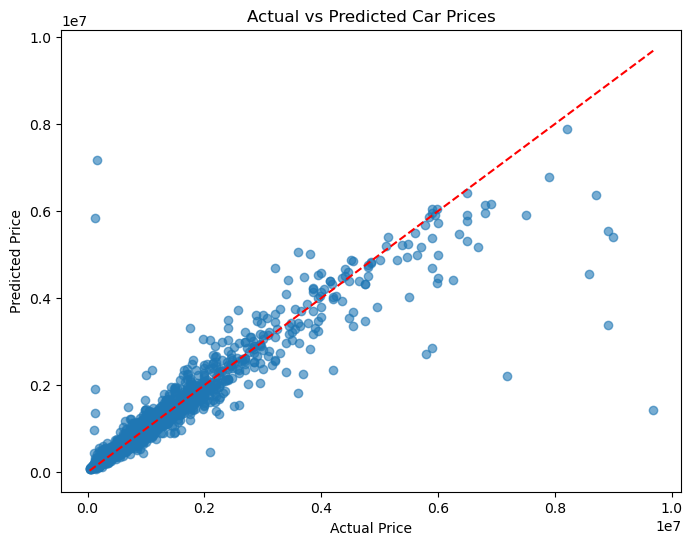

In [63]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

In [64]:
import joblib

joblib.dump(pipe, "car_resale_prediction/car_resale_price_model.pkl")
print("Model saved successfully")

Model saved successfully
